# 🌍 Séismes — Entraînement des modèles ML
**PFE 2026 — Suivi des Catastrophes Naturelles au Maroc**

- **Target :** `severity_label` (low / medium / high)
- **Dataset :** `data_seismes.csv`
- **Modèles :** Régression Logistique, Arbre de Décision, Random Forest

In [5]:
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données

Shape : (2225, 8)

Valeurs manquantes :
time              0
latitude          0
longitude         0
depth             0
mag               0
magType           0
place             0
severity_label    0
dtype: int64

Distribution severity_label :
severity_label
low       1367
medium     750
high       108
Name: count, dtype: int64


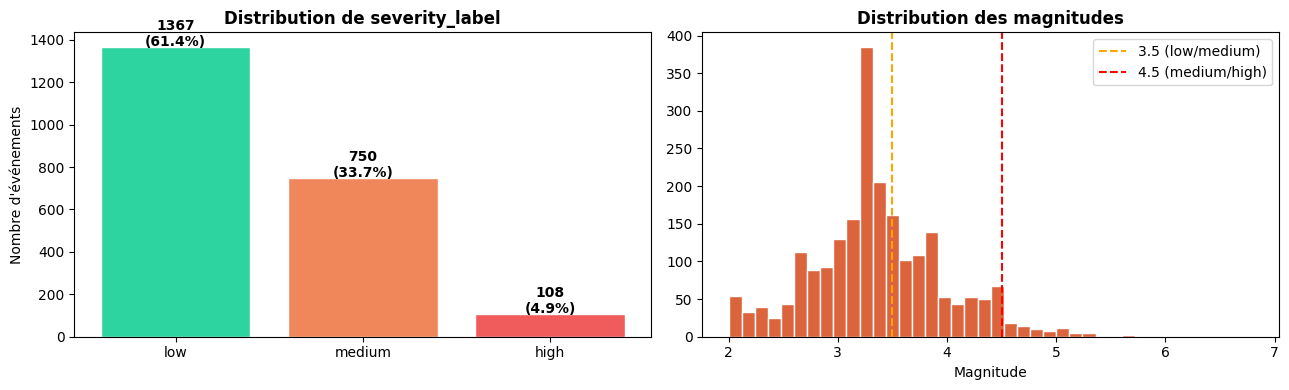

,time,latitude,longitude,depth,mag,magType,place,severity_label
0,2025-12-24 22:43:26.824000+00:00,34.0687,-5.5488,10.000,4.1,mb,"19 km N of Meknès, Morocco",medium
1,2025-09-03 03:25:59.350000+00:00,31.0111,-8.2571,9.076,4.5,mb,"43 km WSW of Oukaïmedene, Morocco",high
2,2025-05-23 11:16:40.499000+00:00,33.4409,-6.2869,10.000,3.8,mb,"26 km W of Oulmes, Morocco",medium
3,2025-02-10 22:48:41.585000+00:00,35.0177,-5.5251,29.521,5.1,mb,"25 km N of Ouezzane, Morocco",high
4,2024-10-15 09:01:40.391000+00:00,33.1723,-5.1420,10.000,4.5,mb,"22 km SE of Aïn Leuh, Morocco",high


In [6]:
df = pd.read_csv('../data/data_seismes.csv')

print(f'Shape : {df.shape}')
print('\nValeurs manquantes :')
print(df.isnull().sum())
print('\nDistribution severity_label :')
print(df['severity_label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['severity_label'].value_counts()
bar_colors = ['#2dd4a0', '#f0875a', '#f05c5c']
axes[0].bar(counts.index, counts.values, color=bar_colors, edgecolor='white')
for i, (lbl, cnt) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, cnt + 3, f'{cnt}\n({cnt/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribution de severity_label', fontweight='bold')
axes[0].set_ylabel("Nombre d'événements")

axes[1].hist(df['mag'], bins=40, color='#dc643c', edgecolor='white')
axes[1].axvline(3.5, color='orange', linestyle='--', label='3.5 (low/medium)')
axes[1].axvline(4.5, color='red',    linestyle='--', label='4.5 (medium/high)')
axes[1].set_title('Distribution des magnitudes', fontweight='bold')
axes[1].set_xlabel('Magnitude')
axes[1].legend()

plt.tight_layout()
plt.show()
df.head()

## 2. Preprocessing

In [7]:
# Supprimer colonnes inutiles pour le ML
df_clean = df.drop(columns=['time', 'place'], errors='ignore').copy()
df_clean = df_clean.dropna(subset=['latitude', 'longitude', 'depth',
                                    'mag', 'magType', 'severity_label'])
print(f'Shape après nettoyage : {df_clean.shape}')

# Encoder magType
le_mag = LabelEncoder()
df_clean['magType_encoded'] = le_mag.fit_transform(df_clean['magType'])
print(f'Classes magType : {list(le_mag.classes_)}')

# Encoder la target severity_label
le_target = LabelEncoder()
df_clean['target'] = le_target.fit_transform(df_clean['severity_label'])
print(f'Classes target  : {list(le_target.classes_)}  (ordre alphabetique)')

# Features — mag EXCLU (data leakage : severity_label est construit depuis mag)
# Feature engineering géophysique
df_clean['depth_log']      = np.log1p(df_clean['depth'])
df_clean['depth_sq']       = df_clean['depth'] ** 2
df_clean['depth_shallow']  = (df_clean['depth'] < 30).astype(int)
df_clean['depth_mid']      = ((df_clean['depth'] >= 30) & (df_clean['depth'] < 70)).astype(int)
df_clean['dist_to_center'] = np.sqrt(
    (df_clean['latitude']  - 31.79) ** 2 +
    (df_clean['longitude'] - (-7.09)) ** 2
)
df_clean['lat_lon_interact'] = df_clean['latitude'] * df_clean['longitude']
df_clean['depth_dist']       = df_clean['depth'] * df_clean['dist_to_center']

FEATURES = [
    'latitude', 'longitude',
    'depth', 'depth_log', 'depth_sq',
    'depth_shallow', 'depth_mid',
    'dist_to_center', 'lat_lon_interact', 'depth_dist',
    'magType_encoded'
]

X = df_clean[FEATURES]
y = df_clean['target']

# Normalisation (nécessaire pour la Régression Logistique)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nNombre de features : {len(FEATURES)}')
print('Features :', FEATURES)
print('Shape X  :', X_scaled.shape)
print('\nDistribution y :')
print(pd.Series(y).value_counts())

Shape après nettoyage : (2225, 6)
Classes magType : ['m', 'mb', 'mblg', 'md', 'ml', 'ms', 'mw', 'mwb', 'mwc', 'mwr', 'mww']
Classes target  : ['high', 'low', 'medium']  (ordre alphabetique)

Nombre de features : 11
Features : ['latitude', 'longitude', 'depth', 'depth_log', 'depth_sq', 'depth_shallow', 'depth_mid', 'dist_to_center', 'lat_lon_interact', 'depth_dist', 'magType_encoded']
Shape X  : (2225, 11)

Distribution y :
target
1    1367
2     750
0     108
Name: count, dtype: int64


## 3. Split Train/Test + SMOTE

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f'Train avant SMOTE : {X_train.shape[0]}')
print(f'Test              : {X_test.shape[0]}')
print('Distribution train avant SMOTE :', dict(pd.Series(y_train).value_counts()))

# SMOTE uniquement sur le train — jamais sur le test !
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f'\nTrain après SMOTE : {X_train.shape[0]}')
print('Distribution train après SMOTE :')
classes, counts = np.unique(y_train, return_counts=True)
for c, n in zip(classes, counts):
    print(f'  {le_target.classes_[c]} ({c}) : {n}')

Train avant SMOTE : 1557
Test              : 668
Distribution train avant SMOTE : {1: np.int64(957), 2: np.int64(525), 0: np.int64(75)}

Train après SMOTE : 2871
Distribution train après SMOTE :
  high (0) : 957
  low (1) : 957
  medium (2) : 957


## 4. Entraînement des 3 modèles

In [9]:
# ── Modèle 1 : Régression Logistique ─────────────────────────────
lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42,
    solver='saga',
    C=0.5
)
lr.fit(X_train, y_train)
print('✅ Régression Logistique entraînée')

# ── Modèle 2 : Arbre de Décision ──────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)
print('✅ Arbre de Décision entraîné')

# ── Modèle 3 : Random Forest ──────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('✅ Random Forest entraîné')

✅ Régression Logistique entraînée
✅ Arbre de Décision entraîné
✅ Random Forest entraîné


## 5. Métriques détaillées

In [10]:
LABELS = list(le_target.classes_)   # ['high', 'low', 'medium']

lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

lr_f1 = f1_score(y_test, lr_pred, average='weighted')
dt_f1 = f1_score(y_test, dt_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print('=' * 58)
print('  RÉGRESSION LOGISTIQUE')
print('=' * 58)
print(f'  Accuracy : {lr_acc*100:.2f}%  |  F1 (weighted) : {lr_f1:.4f}')
print(classification_report(y_test, lr_pred, target_names=LABELS))

print('=' * 58)
print('  ARBRE DE DÉCISION')
print('=' * 58)
print(f'  Accuracy : {dt_acc*100:.2f}%  |  F1 (weighted) : {dt_f1:.4f}')
print(classification_report(y_test, dt_pred, target_names=LABELS))

print('=' * 58)
print('  RANDOM FOREST')
print('=' * 58)
print(f'  Accuracy : {rf_acc*100:.2f}%  |  F1 (weighted) : {rf_f1:.4f}')
print(classification_report(y_test, rf_pred, target_names=LABELS))

  RÉGRESSION LOGISTIQUE
  Accuracy : 50.60%  |  F1 (weighted) : 0.5471
              precision    recall  f1-score   support

        high       0.12      0.64      0.20        33
         low       0.74      0.56      0.64       410
      medium       0.49      0.40      0.44       225

    accuracy                           0.51       668
   macro avg       0.45      0.53      0.42       668
weighted avg       0.63      0.51      0.55       668

  ARBRE DE DÉCISION
  Accuracy : 62.57%  |  F1 (weighted) : 0.6306
              precision    recall  f1-score   support

        high       0.28      0.39      0.33        33
         low       0.76      0.73      0.75       410
      medium       0.46      0.47      0.46       225

    accuracy                           0.63       668
   macro avg       0.50      0.53      0.51       668
weighted avg       0.64      0.63      0.63       668

  RANDOM FOREST
  Accuracy : 65.27%  |  F1 (weighted) : 0.6602
              precision    recall  f1

## 6. Matrices de confusion

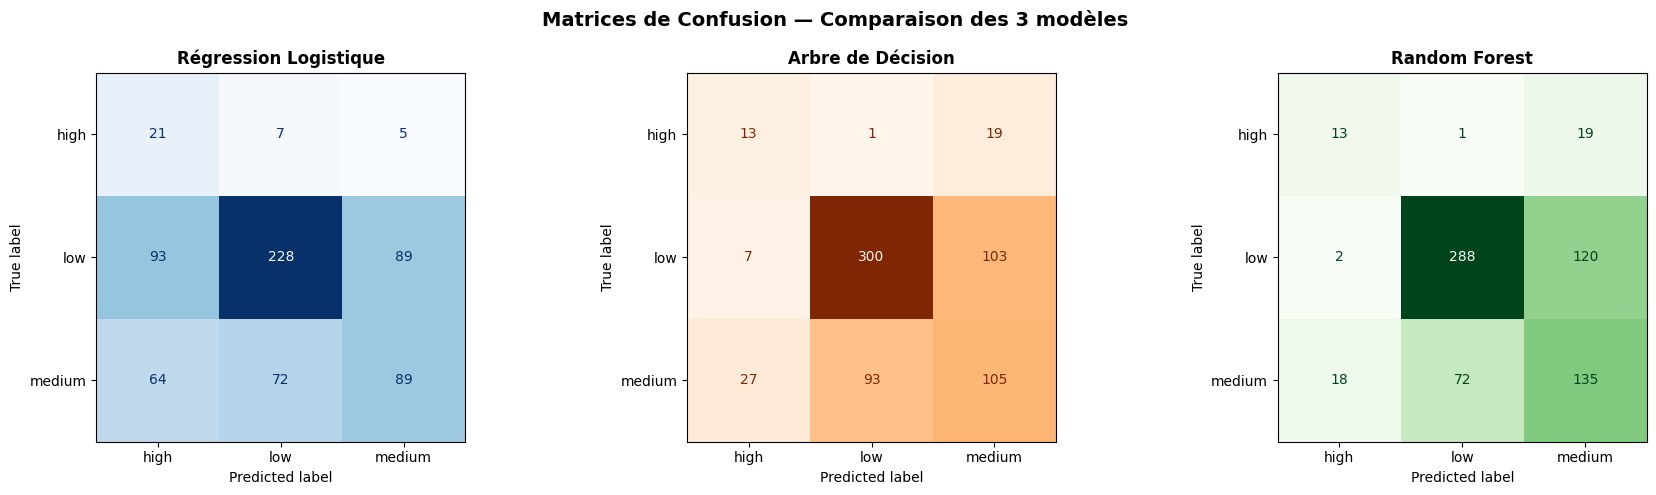

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusion — Comparaison des 3 modèles',
             fontsize=14, fontweight='bold')

configs = [
    ('Régression Logistique', lr_pred, 'Blues'),
    ('Arbre de Décision',     dt_pred, 'Oranges'),
    ('Random Forest',         rf_pred, 'Greens'),
]

for ax, (title, pred, cmap) in zip(axes, configs):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Comparaison des modèles

               Modèle  Accuracy (%)  F1 (weighted)
Régression Logistique         50.60         0.5471
    Arbre de Décision         62.57         0.6306
        Random Forest         65.27         0.6602


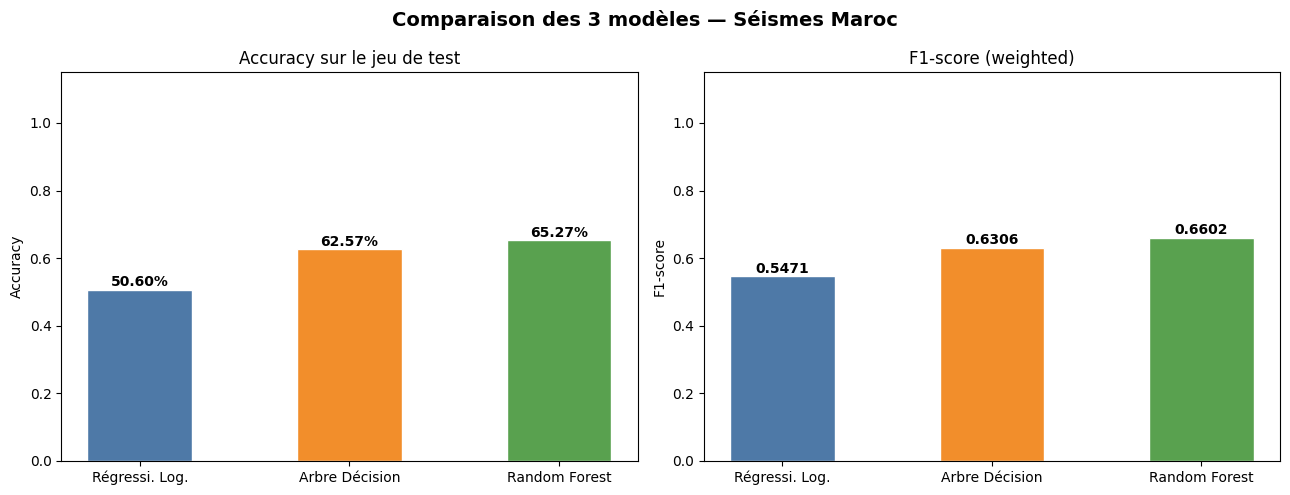


🏆 Meilleur modèle (F1) : Random Forest


In [12]:
# Tableau récapitulatif
results = pd.DataFrame({
    'Modèle'        : ['Régression Logistique', 'Arbre de Décision', 'Random Forest'],
    'Accuracy (%)'  : [round(lr_acc*100, 2), round(dt_acc*100, 2), round(rf_acc*100, 2)],
    'F1 (weighted)' : [round(lr_f1, 4), round(dt_f1, 4), round(rf_f1, 4)],
})
print(results.to_string(index=False))

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparaison des 3 modèles — Séismes Maroc',
             fontsize=14, fontweight='bold')

modeles     = ['Régressi. Log.', 'Arbre Décision', 'Random Forest']
bar_colors  = ['#4e79a7', '#f28e2b', '#59a14f']

accs = [lr_acc, dt_acc, rf_acc]
bars = axes[0].bar(modeles, accs, color=bar_colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v*100:.2f}%', ha='center', fontweight='bold')
axes[0].set_title('Accuracy sur le jeu de test')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.15)

f1s  = [lr_f1, dt_f1, rf_f1]
bars2 = axes[1].bar(modeles, f1s, color=bar_colors, edgecolor='white', width=0.5)
for bar, v in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_title('F1-score (weighted)')
axes[1].set_ylabel('F1-score')
axes[1].set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

# Meilleur modèle automatique
best_idx   = results['F1 (weighted)'].idxmax()
best_name  = results.loc[best_idx, 'Modèle']
model_map  = {
    'Régression Logistique': lr,
    'Arbre de Décision'    : dt,
    'Random Forest'        : rf,
}
best_model = model_map[best_name]
print(f'\n🏆 Meilleur modèle (F1) : {best_name}')

 8. Export du modèle choisi (.pkl) (Aprés la décision final)

In [14]:
# ⏳ Exécuter cette cellule UNIQUEMENT après validation de la coordinatrice

os.makedirs('../models', exist_ok=True)

with open('../models/seisme_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../models/seisme_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/seisme_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_target, f)

print(f'✅ Modèle exporté    : ../models/seisme_model.pkl ({best_name})')
print(f'✅ Scaler exporté    : ../models/seisme_scaler.pkl')
print(f'✅ Encoder exporté   : ../models/seisme_label_encoder.pkl')
print('\nFichiers dans models/ :')
print(os.listdir('../models'))

✅ Modèle exporté    : ../models/seisme_model.pkl (Random Forest)
✅ Scaler exporté    : ../models/seisme_scaler.pkl
✅ Encoder exporté   : ../models/seisme_label_encoder.pkl

Fichiers dans models/ :
['.gitkeep', 'MODELS_README.md', 'seisme_label_encoder.pkl', 'seisme_model.pkl', 'seisme_scaler.pkl']


 9. Résumé — À envoyer à la coordinatrice

| Modèle | Accuracy | F1-score |
|--------|----------|----------|
| Régression Logistique | 50.60|54.71 |
| Arbre de Décision | 62.57|63.06 |
| Random Forest |65.27 |66.02 |

**Modèle retenu :** _____Random Forest__________